# Self-Refine on the small tier

A Self-Refine move costs five model calls instead of one: an initial draft plus
two critique-and-rewrite iterations. This notebook asks whether that fivefold
inference cost buys a measurable improvement in negotiation outcomes, and, if it
does not, what the refinement loop actually does to a move.

The analysis is restricted to the **small tier** (12–14B: Gemma 3 12B,
Ministral 3 14B, Qwen3 14B). The experiment is self-play: in every game both
seats are the same model, and each of the four strategy assignments is run
30 times per model. The assignments are coded by two letters, the first for
Player 1 and the second for Player 2, with `D` = default and `R` = self-refine:

| code | Player 1 | Player 2 |
|------|----------|----------|
| `DD` | default  | default  |
| `RD` | refine   | default  |
| `DR` | default  | refine   |
| `RR` | refine   | refine   |

The `RD` and `DR` cells are the workhorses: each isolates the effect of adding
refinement to a single seat while the opponent stays on default, which lets us
estimate the refine effect without confounding it with the large first/second
mover asymmetries documented in the benchmark chapter.

In [7]:
import sys, os, json, warnings
from pathlib import Path


def find_repo_root():
    starts = []
    seen = set()

    def add_start(path_like):
        if not path_like:
            return
        try:
            path = Path(path_like).resolve()
        except (FileNotFoundError, OSError, RuntimeError):
            return
        key = str(path)
        if key not in seen:
            seen.add(key)
            starts.append(path)

    if "__file__" in globals():
        add_start(Path(__file__).resolve().parent)
    try:
        add_start(Path.cwd())
    except (FileNotFoundError, OSError, RuntimeError):
        pass
    add_start(os.environ.get("PWD"))
    for start in starts:
        for candidate in (start, *start.parents):
            if ((candidate / ".logs").exists()
                    and (candidate / "configs").exists()
                    and (candidate / "_notebooks").exists()):
                return candidate
    raise FileNotFoundError("Could not find repository root")


ROOT_DIR = find_repo_root()
sys.path.insert(0, str(ROOT_DIR))
sys.path.insert(0, str(ROOT_DIR / "_notebooks" / "oss" / "style"))
sys.path.insert(0, str(ROOT_DIR / "explorer"))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.errors import SettingWithCopyWarning

warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)
warnings.filterwarnings("ignore")

import style
from style import wilson_ci, bootstrap_ci, errbars_from_ci, win_rate, family_of
# Publication design system (_notebooks/oss/style): sans-serif report skin,
# colorblind palette, value-axis gridlines, and constrained layout.
style.apply_thesis_style()
FULL_WIDTH, HALF_WIDTH = style.FULL_WIDTH, style.HALF_WIDTH

NOTEBOOK_NAME = "3_self_refine"
FIG_DIR = ROOT_DIR / "_notebooks" / "oss" / "figures" / NOTEBOOK_NAME
FIG_DIR.mkdir(parents=True, exist_ok=True)


def save_plot(fig, slug):
    """Save without the descriptive whole-figure title (the LaTeX caption supplies
    it); keep panel titles and keep the title for the inline display. Writes a PNG."""
    hidden = []
    sup = getattr(fig, "_suptitle", None)
    if sup is not None and sup.get_text():
        sup.set_visible(False); hidden.append(sup)
    real_axes = [a for a in fig.axes if a.get_label() != "<colorbar>"]
    if len(real_axes) == 1 and real_axes[0].get_title():
        t = real_axes[0].title
        t.set_visible(False); hidden.append(t)
    for ext in ("png",):
        fig.savefig(FIG_DIR / f"{slug}.{ext}", dpi=300, bbox_inches="tight")
    for artist in hidden:
        artist.set_visible(True)
    return FIG_DIR / f"{slug}.png"


SIZE = "small"
GAME_ORDER = ["Trading", "Ultimatum", "BuySell"]
COND_ORDER = ["DD", "RD", "DR", "RR"]
COND_LABEL = {"DD": "default", "RD": "refine P1", "DR": "refine P2", "RR": "both refine"}
# Strategy-condition palette (grey baseline, blue single-seat refine, green both).
COND_COLORS = {"DD": "#8C8C8C", "RD": "#0173b2", "DR": "#56b4e9", "RR": "#029e73"}
# Focal-party setting palette for the seat-controlled comparison.
SETTING_ORDER = ["default", "refine", "both"]
SETTING_LABEL = {"default": "default", "refine": "refine (one seat)", "both": "both refine"}
SETTING_COLORS = {"default": "#8C8C8C", "refine": "#0173b2", "both": "#029e73"}
# Process direction palette (matches the Streamlit page).
DIRECTION_ORDER = ["more_selfish", "unchanged", "more_generous", "no_proposal"]
DIRECTION_LABEL = {"more_selfish": "more selfish", "unchanged": "unchanged",
                   "more_generous": "more generous", "no_proposal": "no proposal"}
DIRECTION_COLORS = {"more_selfish": "#d55e00", "unchanged": "#8C8C8C",
                    "more_generous": "#0173b2", "no_proposal": "#ece133"}
GAME_NATIVE_UNIT = {"Trading": "resource delta", "Ultimatum": "dollars kept",
                    "BuySell": "surplus (ZUP)"}

## Data

Outcomes come from the per-run `game_state.json` files via the project's
outcome loaders; the refinement process comes from the per-turn
`refine_trace_*.json` files via the trace loaders. Both are filtered to the
small tier. Payoff is reported in each game's native unit: net resource change
in Trading, dollars kept in Ultimatum, and surplus over the reservation value in
BuySell.

In [8]:
from analysis.self_refine import (
    load_trading_sr, load_ultimatum_sr, load_buysell_sr, completion_rows,
)
from analysis.self_refine_process import load_trace_rows, load_trace_summary

OUT = {
    "Trading": load_trading_sr(SIZE),
    "Ultimatum": load_ultimatum_sr(SIZE),
    "BuySell": load_buysell_sr(SIZE),
}
for g, df in OUT.items():
    df["game"] = g
    df["family"] = df["model"].map(family_of)

COMP = completion_rows(SIZE)
TRACE = load_trace_rows()
TRACE = TRACE[TRACE["size"] == SIZE].copy()
TSUM = load_trace_summary()
TSUM = TSUM[TSUM["size"] == SIZE].copy()

# Sample sizes: completed decisive games underpin every win rate, so show them.
size_tbl = []
for g, df in OUT.items():
    for c in COND_ORDER:
        sub = df[df["cond"] == c]
        decisive = int((sub["win_1"] | sub["win_2"]).sum())
        size_tbl.append({"game": g, "cond": c, "completed": len(sub),
                         "decisive": decisive})
size_tbl = pd.DataFrame(size_tbl).pivot_table(
    index="game", columns="cond", values=["completed", "decisive"]).reindex(GAME_ORDER)
print("Completed runs / decisive (non-tied) games per game x condition:\n")
print(size_tbl.to_string())

2026-06-16 09:40:36.952 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 09:40:39.383 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


Completed runs / decisive (non-tied) games per game x condition:

          completed                   decisive                  
cond             DD    DR    RD    RR       DD    DR    RD    RR
game                                                            
Trading        73.0  88.0  86.0  84.0     57.0  73.0  78.0  76.0
Ultimatum      80.0  89.0  83.0  78.0     59.0  67.0  59.0  62.0
BuySell        84.0  88.0  87.0  87.0     70.0  82.0  78.0  85.0


## 1. Completion

One of the five critique axes is *format*: whether every required tag is present
and parseable. If refinement helps anywhere mechanically rather than
strategically, it is here, by catching a malformed move before it is committed.
Completion on the small tier is already high, so the question is whether
refinement closes the remaining gap.

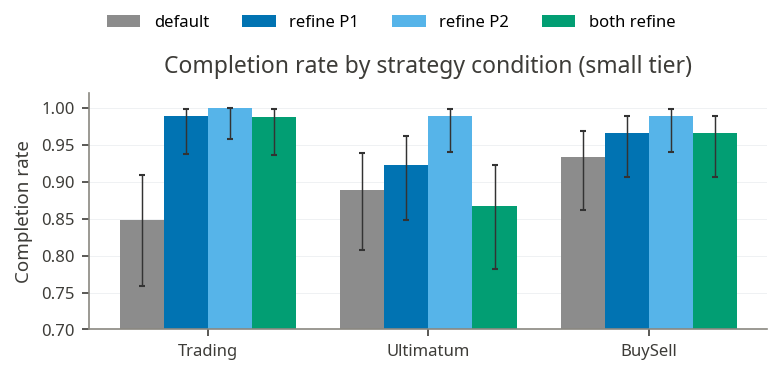

cond          DD     RD     DR     RR
game                                 
Trading    0.849  0.989  1.000  0.988
Ultimatum  0.889  0.922  0.989  0.867
BuySell    0.933  0.967  0.989  0.967


In [9]:
cc = (COMP.groupby(["game", "cond"])
      .agg(k=("completed", "sum"), n=("completed", "count")).reset_index())
cc["rate"] = cc["k"] / cc["n"]
cc[["lo", "hi"]] = cc.apply(lambda r: pd.Series(wilson_ci(r.k, r.n)), axis=1)

x = np.arange(len(GAME_ORDER)); width = 0.2
fig, ax = plt.subplots(figsize=(FULL_WIDTH * 0.85, 2.4))
for i, c in enumerate(COND_ORDER):
    sub = cc[cc["cond"] == c].set_index("game").reindex(GAME_ORDER)
    pos = x + (i - 1.5) * width
    ax.bar(pos, sub["rate"], width, label=COND_LABEL[c], color=COND_COLORS[c])
    ax.errorbar(pos, sub["rate"],
                yerr=errbars_from_ci(sub["rate"].values, list(zip(sub["lo"], sub["hi"]))),
                fmt="none", ecolor="0.2", lw=0.7, capsize=1.5)
ax.set_xticks(x, GAME_ORDER); ax.set_ylabel("Completion rate"); ax.set_ylim(0.7, 1.02)
ax.set_title("Completion rate by strategy condition (small tier)")
fig.legend(*ax.get_legend_handles_labels(), loc="outside upper center", ncols=4, frameon=False)
save_plot(fig, "completion_by_condition"); 
plt.show()

print(cc.pivot_table(index="game", columns="cond", values="rate")
      .reindex(index=GAME_ORDER, columns=COND_ORDER).round(3).to_string())

Completion ranges from 0.85 to 1.00. It is flat across conditions in
Ultimatum and BuySell, where the four intervals overlap. Trading is the
exception: the both-default cell completes 0.849 [0.758, 0.909], while every
condition containing a refiner completes at least 0.988, intervals that do not
overlap. In the one game where the small tier still drops moves on default, a
refiner in the loop recovers them by rewriting the move before it is committed.
(Section 4 shows the *format* critique axis itself almost never fires, so this is a
byproduct of rewriting rather than the critic explicitly catching a malformed
tag.) This is the clearest mechanical benefit refinement provides; whether it also
improves the negotiated outcome is the next question.

## 2. Does refinement change the outcome?

To estimate the effect of refinement cleanly we hold the seat fixed and compare
the focal party with and without the loop, keeping its opponent on default:

- **refine (one seat)** pools Player 1 in `RD` with Player 2 in `DR`,
- against the matched **default** baseline of Player 1 and Player 2 in `DD`,
- and **both refine** pools both seats of `RR`.

Pooling one P1-seat group with one P2-seat group keeps the comparison balanced
across the strong first/second-mover asymmetry, so any gap between the bars is
attributable to refinement rather than to seating.

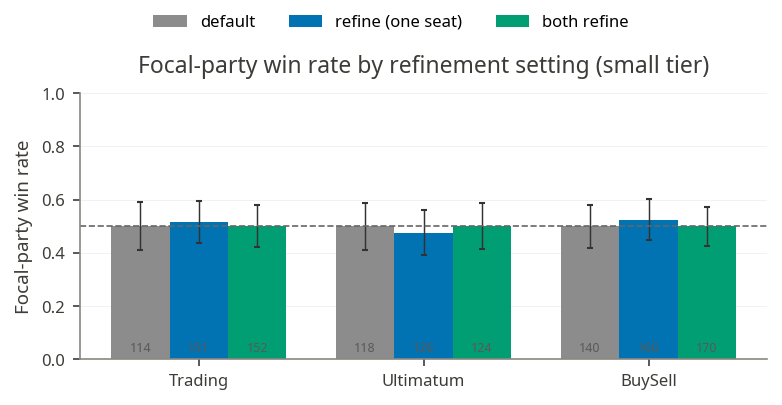

setting    default  refine  both
game                            
Trading        0.5   0.517   0.5
Ultimatum      0.5   0.476   0.5
BuySell        0.5   0.525   0.5


In [10]:
def focal_frame(df):
    """Long frame of the focal party's outcome, seat-balanced, by setting."""
    recs = []

    def add(sub, seat, setting):
        if seat == 1:
            pay, w, l = sub["payoff_1"], sub["win_1"], sub["win_2"]
        else:
            pay, w, l = sub["payoff_2"], sub["win_2"], sub["win_1"]
        for p, win, loss in zip(pay, w, l):
            recs.append(dict(setting=setting, seat=seat, payoff=float(p),
                             win=bool(win), loss=bool(loss)))

    add(df[df["cond"] == "DD"], 1, "default"); add(df[df["cond"] == "DD"], 2, "default")
    add(df[df["cond"] == "RD"], 1, "refine");  add(df[df["cond"] == "DR"], 2, "refine")
    add(df[df["cond"] == "RR"], 1, "both");    add(df[df["cond"] == "RR"], 2, "both")
    return pd.DataFrame(recs)


FOCAL = {g: focal_frame(df) for g, df in OUT.items()}

# Win rate (ties excluded) of the focal party, with Wilson CIs.
rows = []
for g, ff in FOCAL.items():
    for s in SETTING_ORDER:
        sub = ff[ff["setting"] == s]
        wins, losses = int(sub["win"].sum()), int(sub["loss"].sum())
        rate, k, n = win_rate(wins, losses)
        lo, hi = wilson_ci(k, n)
        rows.append(dict(game=g, setting=s, rate=rate, k=k, n=n, lo=lo, hi=hi))
wr = pd.DataFrame(rows)

x = np.arange(len(GAME_ORDER)); width = 0.26
fig, ax = plt.subplots(figsize=(FULL_WIDTH * 0.85, 2.6))
for i, s in enumerate(SETTING_ORDER):
    sub = wr[wr["setting"] == s].set_index("game").reindex(GAME_ORDER)
    pos = x + (i - 1) * width
    ax.bar(pos, sub["rate"], width, label=SETTING_LABEL[s], color=SETTING_COLORS[s])
    ax.errorbar(pos, sub["rate"],
                yerr=errbars_from_ci(sub["rate"].values, list(zip(sub["lo"], sub["hi"]))),
                fmt="none", ecolor="0.2", lw=0.7, capsize=1.5)
    for xp, r, n in zip(pos, sub["rate"], sub["n"]):
        if np.isfinite(r):
            ax.annotate(f"{int(n)}", (xp, 0.02), ha="center", va="bottom",
                        fontsize=6, color="0.35")
ax.axhline(0.5, ls="--", lw=0.8, color="0.4")
ax.set_xticks(x, GAME_ORDER); ax.set_ylabel("Focal-party win rate"); ax.set_ylim(0, 1.0)
ax.set_title("Focal-party win rate by refinement setting (small tier)")
fig.legend(*ax.get_legend_handles_labels(), loc="outside upper center", ncols=3, frameon=False)
save_plot(fig, "winrate_refine_effect"); plt.show()

print(wr.assign(rate=wr["rate"].round(3))
        .pivot_table(index="game", columns="setting", values="rate")
        .reindex(index=GAME_ORDER, columns=SETTING_ORDER).to_string())

Win rate is a within-pair quantity: in self-play one seat's win is the
other's loss, so a value near 0.5 means the seat the refiner happens to occupy is
neither helped nor hurt relative to a default opponent. The dashed line marks
that parity; the *default* baseline sits exactly on it by construction, since
pooling both seats of a self-play game forces wins to equal losses. Read against
that line, the focal-party win rate moves little when one seat adds refinement —
0.52 in Trading, 0.48 in Ultimatum, 0.53 in BuySell — and every *refine* Wilson
interval contains 0.5. The payoff view below carries the units the win rate
discards.

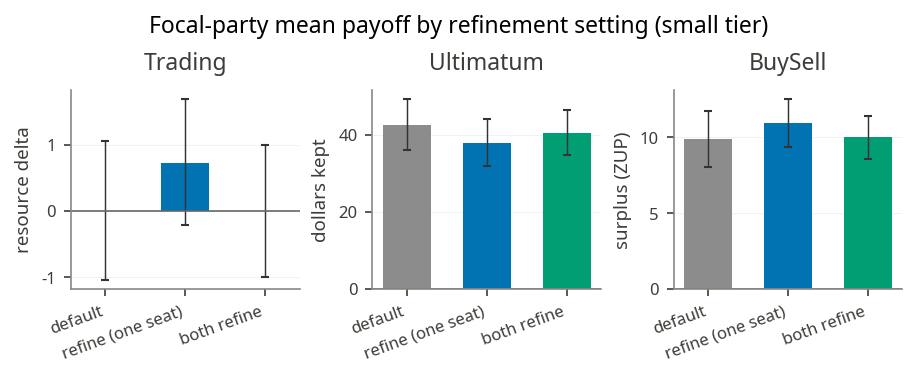

Trading    default=  0.00  refine=  0.73  delta=+0.73 (resource delta)
Ultimatum  default= 42.50  refine= 37.87  delta=-4.63 (dollars kept)
BuySell    default=  9.88  refine= 10.94  delta=+1.06 (surplus (ZUP))


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(FULL_WIDTH, 2.4))
for ax, g in zip(axes, GAME_ORDER):
    ff = FOCAL[g]
    centers, los, his = [], [], []
    for s in SETTING_ORDER:
        vals = ff[ff["setting"] == s]["payoff"].values
        centers.append(np.mean(vals))
        lo, hi = bootstrap_ci(vals)
        los.append(lo); his.append(hi)
    pos = np.arange(len(SETTING_ORDER))
    ax.bar(pos, centers, 0.6, color=[SETTING_COLORS[s] for s in SETTING_ORDER])
    ax.errorbar(pos, centers,
                yerr=errbars_from_ci(centers, list(zip(los, his))),
                fmt="none", ecolor="0.2", lw=0.7, capsize=2)
    ax.axhline(0, lw=0.8, color="0.4")
    ax.set_xticks(pos, [SETTING_LABEL[s] for s in SETTING_ORDER], rotation=20, ha="right")
    ax.set_title(g); ax.set_ylabel(GAME_NATIVE_UNIT[g])
fig.suptitle("Focal-party mean payoff by refinement setting (small tier)")
save_plot(fig, "payoff_refine_effect"); plt.show()

for g in GAME_ORDER:
    ff = FOCAL[g]
    base = ff[ff["setting"] == "default"]["payoff"].values
    ref = ff[ff["setting"] == "refine"]["payoff"].values
    delta = np.mean(ref) - np.mean(base)
    print(f"{g:10s} default={np.mean(base):6.2f}  refine={np.mean(ref):6.2f}  "
          f"delta={delta:+5.2f} ({GAME_NATIVE_UNIT[g]})")

<!-- INSIGHTS_OUTCOME -->
Across all three games the *refine* bar lands within the bootstrap interval of
the *default* bar, and *both refine* does not separate either. Spending five
calls per move in place of one does not move the focal party's payoff at the
small tier. The outcome is flat; the next section asks whether the moves
themselves are flat, or whether refinement is changing the move in a way that
the opponent simply absorbs.

## 2b. Refining the first mover is not the same as refining the second

The pooled estimate above balances the two single-seat conditions on purpose, so
that no first/second-mover asymmetry can leak into the refine effect. But that
balancing is only valid if refining Player 1 and refining Player 2 are the *same*
intervention — and the two seats start from very different places. In `DD` the
first mover loses Trading heavily and dominates Ultimatum, so adding refinement to
a seat that is already winning is not the same experiment as adding it to a seat
that is losing. Pooling a helped seat with a hurt one can cancel to the flat
result of Section 2.

This section unpacks the pool. It compares each seat against its own
seat-matched `DD` baseline, never mixing seats:

- **refine P1** is Player 1 in `RD` versus Player 1 in `DD`,
- **refine P2** is Player 2 in `DR` versus Player 2 in `DD`,
- **both refine** is each seat read from `RR`.

So the figure carries each seat's default level, the effect of refining only that
seat, and the effect of refining both — and the two single-seat effects can be
read off and compared directly instead of averaged together.

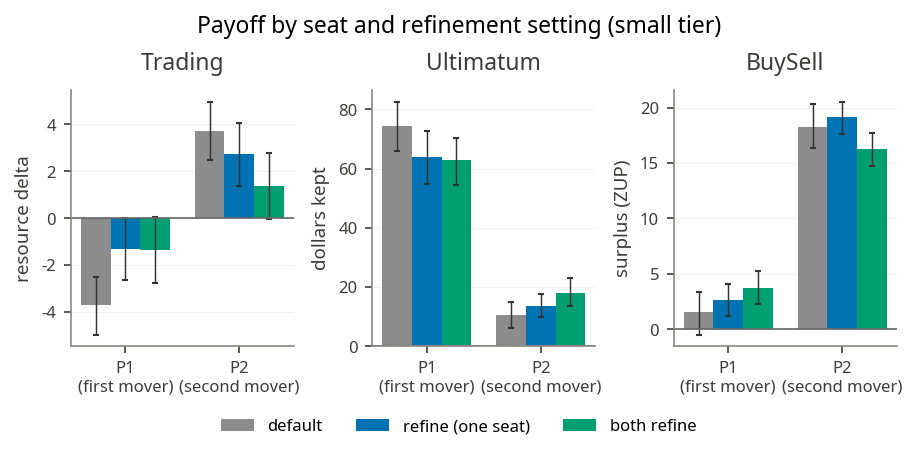

Seat-specific refine effect (refine that seat - DD baseline, same seat):

game       seat   default   refine    delta           95% CI     winrate D->R
Trading    P1       -3.70    -1.30    +2.40 [ +0.57, +4.21]    0.18 -> 0.38
Trading    P2        3.70     2.72    -0.98 [ -2.77, +0.79]    0.82 -> 0.66
Ultimatum  P1       74.50    63.90   -10.60 [-22.67, +1.82]    0.98 -> 0.95
Ultimatum  P2       10.50    13.58    +3.08 [ -2.47, +8.92]    0.02 -> 0.06
BuySell    P1        1.55     2.68    +1.13 [ -1.23, +3.66]    0.14 -> 0.13
BuySell    P2       18.21    19.10    +0.89 [ -1.58, +3.32]    0.86 -> 0.90


In [12]:
# Seat-resolved view: each seat's payoff under its own default (DD), under
# refining only that seat (RD for P1, DR for P2), and under both refining (RR).
# Every comparison is against the seat-matched DD baseline, so no first/second
# mover asymmetry leaks in -- and the P1 and P2 effects stay separate.
SEAT_SETTING = ["default", "refine", "both"]  # reuse SETTING_* palette/labels

def seat_payoff(df, seat, setting):
    col = "payoff_1" if seat == 1 else "payoff_2"
    cond = {(1, "default"): "DD", (1, "refine"): "RD", (1, "both"): "RR",
            (2, "default"): "DD", (2, "refine"): "DR", (2, "both"): "RR"}[(seat, setting)]
    return df[df["cond"] == cond][col].values.astype(float)

def seat_winrate(df, seat, setting):
    cond = {(1, "default"): "DD", (1, "refine"): "RD", (1, "both"): "RR",
            (2, "default"): "DD", (2, "refine"): "DR", (2, "both"): "RR"}[(seat, setting)]
    sub = df[df["cond"] == cond]
    if seat == 1:
        w, l = int(sub["win_1"].sum()), int(sub["win_2"].sum())
    else:
        w, l = int(sub["win_2"].sum()), int(sub["win_1"].sum())
    rate, k, n = win_rate(w, l)
    return rate, k, n

def _diff_ci(ref, base, n=4000, seed=0):
    ref, base = np.asarray(ref, float), np.asarray(base, float)
    rng = np.random.default_rng(seed)
    d = [rng.choice(ref, ref.size).mean() - rng.choice(base, base.size).mean()
         for _ in range(n)]
    return float(np.percentile(d, 2.5)), float(np.percentile(d, 97.5))

# Figure: one panel per game; within a panel, two seat groups (P1, P2), each with
# default / refine-this-seat / both bars carrying bootstrap CIs.
fig, axes = plt.subplots(1, 3, figsize=(FULL_WIDTH, 2.9))
group_x = np.arange(2); width = 0.26
for ax, g in zip(axes, GAME_ORDER):
    df = OUT[g]
    for i, s in enumerate(SEAT_SETTING):
        centers, los, his = [], [], []
        for seat in (1, 2):
            vals = seat_payoff(df, seat, s)
            centers.append(np.mean(vals))
            lo, hi = bootstrap_ci(vals)
            los.append(lo); his.append(hi)
        pos = group_x + (i - 1) * width
        ax.bar(pos, centers, width, label=SETTING_LABEL[s], color=SETTING_COLORS[s])
        ax.errorbar(pos, centers,
                    yerr=errbars_from_ci(centers, list(zip(los, his))),
                    fmt="none", ecolor="0.2", lw=0.7, capsize=1.5)
    ax.axhline(0, lw=0.8, color="0.4")
    ax.set_xticks(group_x, ["P1\n(first mover)", "P2\n(second mover)"])
    ax.set_title(g); ax.set_ylabel(GAME_NATIVE_UNIT[g])
fig.suptitle("Payoff by seat and refinement setting (small tier)")
# Legend at the bottom so it never collides with the whole-figure title up top.
fig.legend(*axes[0].get_legend_handles_labels(), loc="outside lower center",
           ncols=3, frameon=False)
save_plot(fig, "refine_effect_by_seat"); plt.show()

# Seat-specific effect: refine-this-seat minus the seat-matched DD baseline,
# with a bootstrap CI on the difference, plus the win-rate shift.
print("Seat-specific refine effect (refine that seat - DD baseline, same seat):\n")
print(f"{'game':10s} {'seat':5s} {'default':>8s} {'refine':>8s} {'delta':>8s} "
      f"{'95% CI':>16s}   {'winrate D->R':>14s}")
for g in GAME_ORDER:
    df = OUT[g]
    for seat in (1, 2):
        base = seat_payoff(df, seat, "default")
        ref = seat_payoff(df, seat, "refine")
        lo, hi = _diff_ci(ref, base)
        bwr, _, _ = seat_winrate(df, seat, "default")
        rwr, _, _ = seat_winrate(df, seat, "refine")
        tag = "P1" if seat == 1 else "P2"
        print(f"{g:10s} {tag:5s} {base.mean():8.2f} {ref.mean():8.2f} "
              f"{ref.mean()-base.mean():+8.2f} [{lo:+6.2f},{hi:+6.2f}]   "
              f"{bwr:5.2f} -> {rwr:4.2f}")


Once the seats are separated, the flat pooled result of Section 2 splits into two
effects that point in opposite directions, and the sign tracks where the seat
started. In **Trading**, where the first mover loses on default (P1 keeps −3.7 in
`DD`), refining only P1 is the one clearly positive intervention in the notebook:
payoff rises +2.40 [+0.57, +4.21] and P1's win rate climbs 0.18 → 0.38, an
interval that clears zero. Refining the already-winning P2 in the same game does
nothing or slightly hurts (−0.98 [−2.77, +0.79]). **Ultimatum** is the mirror
image: the dominant proposer (P1 keeps ~75 on default) *loses* about ten dollars
from refining (−10.60 [−22.67, +1.82]) — the loop talks it into a more generous
split it cannot recover — while the responder gains a little (+3.08). **BuySell**
is the only game where the two seats agree, both nudging up by about a point with
intervals straddling zero. Pooling P1-of-`RD` with P2-of-`DR` was averaging a
helped loser against a hurt winner, which is exactly why Section 2 read as flat.
The takeaway is that refinement is not seat-neutral: it tends to pull whichever
seat runs it toward the *middle* — lifting the disadvantaged first mover in
Trading, dragging the dominant proposer down in Ultimatum — rather than uniformly
helping the party that pays for it.

## 3. What refinement does to a move

Outcomes being flat does not mean the loop is inert. Each refining turn leaves a
trace of the draft and its two rewrites, from which we recover the proposed
offer at each version. `ambition_delta` is defined so that a positive value means
the proposer became **more selfish** between its initial draft and its committed
move (the sign is flipped for the BuySell buyer, whose self-interest runs in the
opposite price direction). `direction` buckets each refined move accordingly.

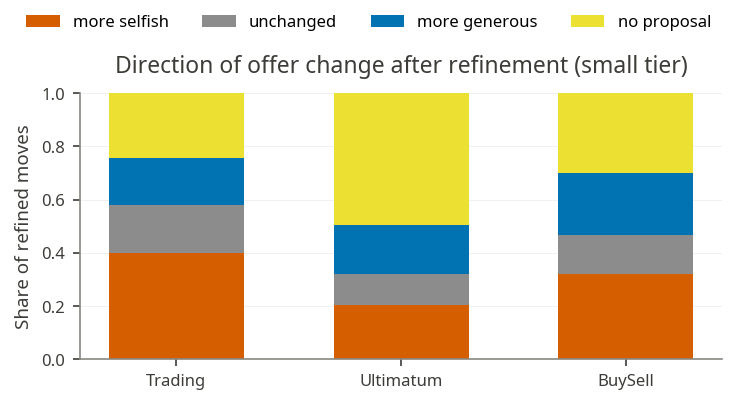

Trading    more-selfish share among changed = 0.69 [0.64, 0.74] (n=366);  mean ambition_delta = +0.96
Ultimatum  more-selfish share among changed = 0.53 [0.44, 0.61] (n=137);  mean ambition_delta = -0.26
BuySell    more-selfish share among changed = 0.58 [0.52, 0.64] (n=256);  mean ambition_delta = +1.58


In [13]:
proc = TSUM.copy()
dd = (proc.groupby(["game", "direction"]).size()
      .rename("n").reset_index())
tot = dd.groupby("game")["n"].transform("sum")
dd["share"] = dd["n"] / tot

games_l = ["trading", "ultimatum", "buysell"]
game_disp = {"trading": "Trading", "ultimatum": "Ultimatum", "buysell": "BuySell"}
x = np.arange(len(games_l))
fig, ax = plt.subplots(figsize=(FULL_WIDTH * 0.8, 2.6))
bottom = np.zeros(len(games_l))
for d in DIRECTION_ORDER:
    vals = (dd[dd["direction"] == d].set_index("game")
            .reindex(games_l)["share"].fillna(0).values)
    ax.bar(x, vals, 0.6, bottom=bottom, label=DIRECTION_LABEL[d], color=DIRECTION_COLORS[d])
    bottom += vals
ax.set_xticks(x, [game_disp[g] for g in games_l])
ax.set_ylabel("Share of refined moves"); ax.set_ylim(0, 1.0)
ax.set_title("Direction of offer change after refinement (small tier)")
fig.legend(*ax.get_legend_handles_labels(), loc="outside upper center", ncols=4, frameon=False)
save_plot(fig, "refine_direction"); plt.show()

# Among moves that did change the offer, how lopsided is the selfish:generous split?
moved = proc[proc["direction"].isin(["more_selfish", "more_generous"])]
for g in games_l:
    sub = moved[moved["game"] == g]
    s = int((sub["direction"] == "more_selfish").sum())
    gen = int((sub["direction"] == "more_generous").sum())
    n = s + gen
    rate, k, nn = win_rate(s, gen)
    lo, hi = wilson_ci(k, nn)
    md_mean = proc[proc["game"] == g]["ambition_delta"].dropna().mean()
    print(f"{game_disp[g]:10s} more-selfish share among changed = {rate:.2f} "
          f"[{lo:.2f}, {hi:.2f}] (n={n});  mean ambition_delta = {md_mean:+.2f}")

Refinement is not a coin flip. In Trading and BuySell the loop pushes the
offer toward the proposer's own advantage more often than away from it, and the
mean `ambition_delta` is positive in both. The critique axis labelled *payoff
alignment* — "does the proposed trade advance the agent's own goal" — is doing
exactly what its name says: it talks the model into asking for more. Ultimatum is
the exception, where the split is closer to even. Yet none of this surfaced in
Section 2, because in self-play the opponent is refining or responding under the
same incentives and absorbs the more selfish ask (Section 5 makes this precise).

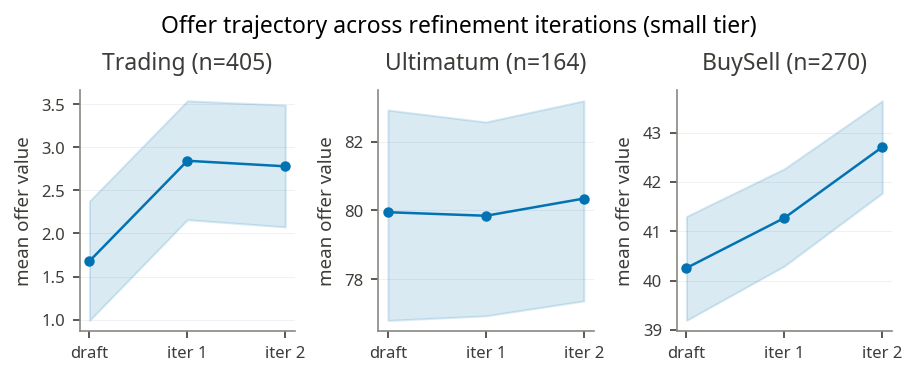

Trading    draft=  1.68 -> iter2=  2.78 (delta +1.10, n=405)
Ultimatum  draft= 79.95 -> iter2= 80.34 (delta +0.40, n=164)
BuySell    draft= 40.26 -> iter2= 42.71 (delta +2.45, n=270)


In [14]:
# Offer trajectory across versions, on matched moves that carry an offer at
# every version (initial -> iter1 -> iter2), so the mean is not biased by
# composition changes between versions.
tr = TRACE.dropna(subset=["offer_value"]).copy()
piv = tr.pivot_table(index=["game", "run_id", "iter_n", "turn_n"],
                     columns="version_idx", values="offer_value")
need = [0, 1, 2]
piv = piv.dropna(subset=[c for c in need if c in piv.columns])
piv = piv.reset_index()

fig, axes = plt.subplots(1, 3, figsize=(FULL_WIDTH, 2.4))
for ax, g in zip(axes, games_l):
    sub = piv[piv["game"] == g]
    centers, los, his = [], [], []
    for v in need:
        vals = sub[v].values.astype(float)
        centers.append(np.mean(vals))
        lo, hi = bootstrap_ci(vals)
        los.append(lo); his.append(hi)
    ax.plot(need, centers, "-o", color="#0173b2", lw=1.2, ms=4)
    ax.fill_between(need, los, his, color="#0173b2", alpha=0.15)
    ax.set_xticks(need, ["draft", "iter 1", "iter 2"])
    ax.set_title(f"{game_disp[g]} (n={len(sub)})")
    ax.set_ylabel("mean offer value")
fig.suptitle("Offer trajectory across refinement iterations (small tier)")
save_plot(fig, "offer_trajectory"); plt.show()

for g in games_l:
    sub = piv[piv["game"] == g]
    print(f"{game_disp[g]:10s} draft={sub[0].mean():6.2f} -> iter2={sub[2].mean():6.2f} "
          f"(delta {sub[2].mean() - sub[0].mean():+5.2f}, n={len(sub)})")

The drift is gradual rather than a single jump: where the offer moves, it
moves across both iterations in the same direction, consistent with the
mostly-monotone trajectories quantified below. The loop is not thrashing between
contradictory rewrites; it is steadily nudging the same move.

In [15]:
# Stability: how often refinement flips the action (accept <-> propose) and how
# often the offer path is monotone (no reversal), among traces with >= 3 versions.
rows = []
for g in games_l:
    sub = proc[proc["game"] == g]
    ac = sub["action_changed"].dropna()
    mono = sub["is_monotone"].dropna()
    rows.append({
        "game": game_disp[g],
        "action_flip_rate": round(ac.mean(), 3) if len(ac) else np.nan,
        "n_action": int(len(ac)),
        "monotone_share": round(mono.mean(), 3) if len(mono) else np.nan,
        "n_monotone": int(len(mono)),
    })
stability = pd.DataFrame(rows).set_index("game")
print(stability.to_string())

           action_flip_rate  n_action  monotone_share  n_monotone
game                                                             
Trading               0.103       631           0.583         405
Ultimatum             0.041       319           0.500         164
BuySell               0.078       460           0.500         270


The action rarely flips: refinement keeps the move type it started with —
propose, accept, or reject — in 90 to 96% of turns. The offer path, where it
spans all three versions, is monotone about half the time (0.50–0.58), so the
gradual drift in the previous figure is an average over both steadily-moving and
reversing moves rather than a uniform march. What refinement reliably edits is the
magnitude of an offer, not the decision behind it.

## 5. Is the more selfish ask absorbed?

Section 3 ended on a claim it did not test: the refined move asks for more, but in
self-play the opponent "absorbs" it, so the outcome stays flat. There are two ways
an opponent could neutralise a greedier ask — by *walking away* (a no-deal that
destroys value for both) or by *conceding* it (accepting the larger demand). This
section separates the two. It contrasts the **intended** ambition shift the loop
writes into a move (from the traces) with the **realized** payoff gain it earns
against a default opponent (from Section 2), and reads the true no-deal rate and,
for Ultimatum, the opening-ask-to-realized concession directly off the game
states.

True no-deal rate (both parties end with nothing) by game x condition:
cond        DD   RD   DR   RR
game                         
Trading    0.0  0.0  0.0  0.0
Ultimatum  0.0  0.0  0.0  0.0
BuySell    0.0  0.0  0.0  0.0


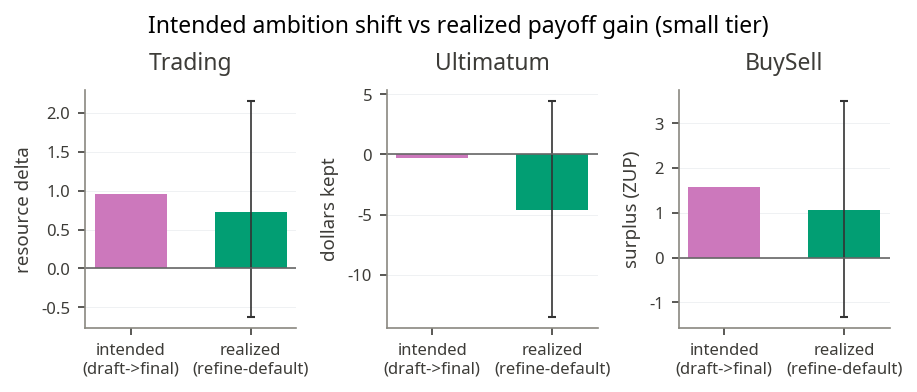

Trading    intended +0.96  ->  realized +0.73 [-0.63, +2.15]
Ultimatum  intended -0.26  ->  realized -4.63 [-13.52, +4.46]
BuySell    intended +1.58  ->  realized +1.06 [-1.33, +3.50]


In [16]:
import re
from analysis.common import resource_value

# Run-level outcomes straight from game_state.json. A *true* no-deal is both
# parties ending with nothing (pot destroyed) -- read from final_resources, NOT
# from the payoff columns: the Ultimatum payoff loader maps both a no-deal AND a
# proposer who greedily keeps the whole pot to payoff 0, so the two must be told
# apart here. For Ultimatum we also recover P1's opening ask and realized keep.
_SRE = re.compile(r"_([a-z_]+)P1_([a-z_]+)P2")
_SHORT = {"default": "D", "self_refine": "R"}
_RUN_EXP = {"Trading": "trading_self_refine_v1", "Ultimatum": "ultimatum_self_refine_v1",
            "BuySell": "buysell_self_refine_v1"}


def load_run_outcomes(size=SIZE):
    rows = []
    for game, exp in _RUN_EXP.items():
        base = ROOT_DIR / ".logs" / "self_refine" / exp / size
        if not base.exists():
            continue
        for gs in base.rglob("game_state.json"):
            try:
                d = json.loads(gs.read_text())
            except Exception:
                continue
            states = d.get("game_state", [])
            if not states or states[-1].get("current_iteration") != "END":
                continue
            s = states[-1].get("summary") or {}
            fr = s.get("final_resources")
            if not fr:
                continue
            cond = "??"
            for part in str(gs).split(os.sep):
                m = _SRE.search(part)
                if m:
                    cond = _SHORT.get(m.group(1), "?") + _SHORT.get(m.group(2), "?")
            try:
                nd = (resource_value(fr[0]) == 0 and resource_value(fr[1]) == 0)
            except Exception:
                nd = None
            rec = dict(game=game, cond=cond, no_deal=nd,
                       opening_keep=np.nan, realized_keep=np.nan)
            if game == "Ultimatum" and len(states) > 1:
                try:
                    v = states[1]["player_public_info_dict"]["newly proposed trade"]["_value"]
                    rec["opening_keep"] = 100 - int(v["RED"]["_value"]["Dollars"])
                except Exception:
                    pass
                try:
                    rec["realized_keep"] = resource_value(fr[0])
                except Exception:
                    pass
            rows.append(rec)
    df = pd.DataFrame(rows)
    df["p1_refine"] = df["cond"].isin(["RD", "RR"])
    return df


RUNS = load_run_outcomes()
print("True no-deal rate (both parties end with nothing) by game x condition:")
print(RUNS.pivot_table(index="game", columns="cond", values="no_deal", aggfunc="mean")
      .reindex(index=GAME_ORDER, columns=COND_ORDER).round(3).to_string())

# Intended ambition shift (draft -> committed move, from the traces) vs the
# realized payoff gain over a default opponent (Section 2's focal frame).
gmap = {"Trading": "trading", "Ultimatum": "ultimatum", "BuySell": "buysell"}
intent, real, real_ci = {}, {}, {}
for g in GAME_ORDER:
    intent[g] = TSUM[TSUM["game"] == gmap[g]]["ambition_delta"].dropna().mean()
    ff = FOCAL[g]
    base = ff[ff["setting"] == "default"]["payoff"].values
    ref = ff[ff["setting"] == "refine"]["payoff"].values
    real[g] = ref.mean() - base.mean()
    rng = np.random.default_rng(0)
    d = [rng.choice(ref, ref.size).mean() - rng.choice(base, base.size).mean() for _ in range(4000)]
    real_ci[g] = (float(np.percentile(d, 2.5)), float(np.percentile(d, 97.5)))

fig, axes = plt.subplots(1, 3, figsize=(FULL_WIDTH, 2.5))
for ax, g in zip(axes, GAME_ORDER):
    ax.bar([0, 1], [intent[g], real[g]], 0.6, color=["#cc78bc", "#029e73"])
    ax.errorbar([1], [real[g]], yerr=errbars_from_ci([real[g]], [real_ci[g]]),
                fmt="none", ecolor="0.2", lw=0.8, capsize=2)
    ax.axhline(0, lw=0.8, color="0.4")
    ax.set_xticks([0, 1], ["intended\n(draft->final)", "realized\n(refine-default)"])
    ax.set_title(g); ax.set_ylabel(GAME_NATIVE_UNIT[g])
fig.suptitle("Intended ambition shift vs realized payoff gain (small tier)")
save_plot(fig, "absorption_intent_vs_realized"); plt.show()

for g in GAME_ORDER:
    lo, hi = real_ci[g]
    print(f"{g:10s} intended {intent[g]:+5.2f}  ->  realized {real[g]:+5.2f} [{lo:+.2f}, {hi:+.2f}]")

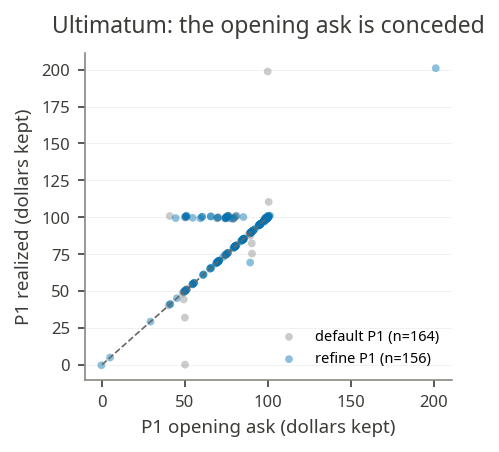

share of Ultimatum games where P1 keeps >= its opening ask: 0.97
            opening_keep  realized_keep
p1_refine                              
default P1          83.6           87.7
refine P1           80.7           85.8


In [17]:
# Ultimatum concession plot: the proposer's opening ask (dollars it keeps at
# turn 0) against what it actually keeps at the end. Points on/above the diagonal
# mean the responder conceded the whole ask (or more). Run-level frame RUNS is
# built in the cell above.
ult = RUNS[RUNS["game"] == "Ultimatum"].dropna(subset=["opening_keep", "realized_keep"]).copy()

fig, ax = plt.subplots(figsize=(HALF_WIDTH, 2.9))
for refine, color, lab in [(False, "#8C8C8C", "default P1"), (True, "#0173b2", "refine P1")]:
    sub = ult[ult["p1_refine"] == refine]
    jit = np.random.default_rng(0).normal(0, 0.6, len(sub))
    ax.scatter(sub["opening_keep"] + jit, sub["realized_keep"] + jit, s=14, alpha=0.45,
               color=color, edgecolor="none", label=f"{lab} (n={len(sub)})")
ax.plot([0, 100], [0, 100], ls="--", lw=0.8, color="0.4")
ax.set_xlabel("P1 opening ask (dollars kept)")
ax.set_ylabel("P1 realized (dollars kept)")
ax.set_title("Ultimatum: the opening ask is conceded")
ax.legend(frameon=False, fontsize=7, loc="lower right")
save_plot(fig, "ultimatum_concession"); plt.show()

above = (ult["realized_keep"] >= ult["opening_keep"]).mean()
print(f"share of Ultimatum games where P1 keeps >= its opening ask: {above:.2f}")
print(ult.groupby("p1_refine")[["opening_keep", "realized_keep"]].mean().round(1)
      .rename(index={False: "default P1", True: "refine P1"}).to_string())

The two views agree. In Trading and BuySell the *intended* shift — how much more
selfish the committed move is than its own draft — is larger than the *realized*
gain over a default opponent (Trading +0.96 asked vs +0.73 kept; BuySell +1.58 vs
+1.06). The opponent concedes part of the extra ask and absorbs the rest, leaving
a realized gain small enough to sit inside the Section 2 intervals. Ultimatum shows
the limiting case directly: true no-deals are essentially absent in every
condition, and the concession plot sits on or above the diagonal, so a proposer
keeps as much as it asks for and usually a little more. Default proposers already
open keeping ~84 dollars and walk away with ~88, so there is no slack for
refinement to capture — its small negative effect comes from occasionally drafting
a *more generous* split that the responder happily pockets. The more selfish ask is
not punished; it is simply matched.

## 6. Who does refinement help?

Section 2 pooled all three small-tier families into one focal-party estimate and
found the refine effect flat. Pooling can hide offsetting effects, though: a model
that gains from refinement and one that loses can average to zero. This section
re-runs the seat-balanced focal comparison of Section 2 family by family — with one
model per family at this tier — to see whether the flat pooled result is genuinely
flat or a cancellation. Bars show the focal party's payoff change from adding
refinement to one seat against a default opponent, with bootstrap intervals on the
difference.

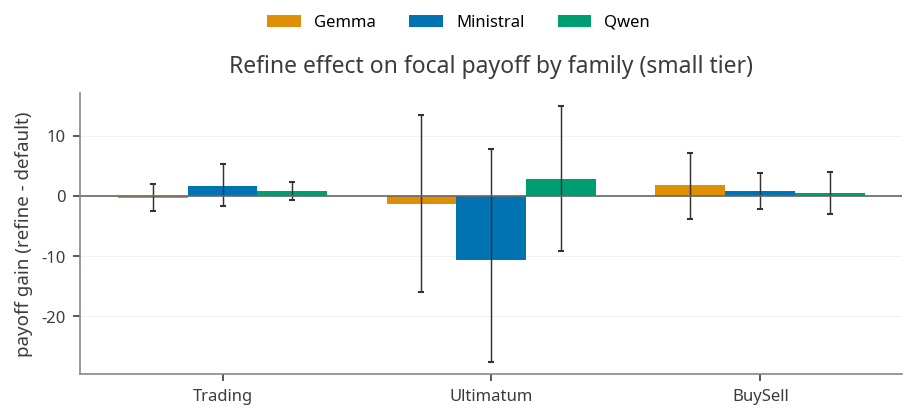

             dpay                       dwr                  
game      BuySell Trading Ultimatum BuySell Trading Ultimatum
family                                                       
gemma        1.81   -0.27     -1.27  -0.009  -0.059    -0.026
ministral    0.82    1.75    -10.57   0.074   0.010    -0.026
qwen         0.52    0.80      2.88   0.017   0.134    -0.016


In [18]:
# Per-family refine effect: the same seat-balanced focal comparison as Section 2,
# but split by model family instead of pooled. The small tier has one model per
# family, so a family is a single model here.
def focal_frame_fam(df):
    """Focal-party records carrying the model/family (Section 2's focal_frame
    drops them)."""
    recs = []

    def add(sub, seat, setting):
        pay = sub["payoff_1"] if seat == 1 else sub["payoff_2"]
        win = sub["win_1"] if seat == 1 else sub["win_2"]
        loss = sub["win_2"] if seat == 1 else sub["win_1"]
        for m, p, w, l in zip(sub["model"], pay, win, loss):
            recs.append(dict(model=m, family=family_of(m), setting=setting,
                             payoff=float(p), win=bool(w), loss=bool(l)))

    add(df[df["cond"] == "DD"], 1, "default"); add(df[df["cond"] == "DD"], 2, "default")
    add(df[df["cond"] == "RD"], 1, "refine");  add(df[df["cond"] == "DR"], 2, "refine")
    return pd.DataFrame(recs)


def _diff_ci(ref, base, n=4000, seed=0):
    ref, base = np.asarray(ref, float), np.asarray(base, float)
    rng = np.random.default_rng(seed)
    d = [rng.choice(ref, ref.size).mean() - rng.choice(base, base.size).mean()
         for _ in range(n)]
    return float(np.percentile(d, 2.5)), float(np.percentile(d, 97.5))


FAMILY_ORDER = ["gemma", "ministral", "qwen"]
FAMILY_LABEL = {"gemma": "Gemma", "ministral": "Ministral", "qwen": "Qwen"}
FAMILY_COLORS = {"gemma": "#de8f05", "ministral": "#0173b2", "qwen": "#029e73"}

rows = []
for g in GAME_ORDER:
    ff = focal_frame_fam(OUT[g])
    for fam in FAMILY_ORDER:
        sub = ff[ff["family"] == fam]
        base = sub[sub["setting"] == "default"]["payoff"].values
        ref = sub[sub["setting"] == "refine"]["payoff"].values
        if not len(base) or not len(ref):
            continue
        dpay = ref.mean() - base.mean()
        lo, hi = _diff_ci(ref, base)
        bw, bl = sub[sub.setting == "default"]["win"].sum(), sub[sub.setting == "default"]["loss"].sum()
        rw, rl = sub[sub.setting == "refine"]["win"].sum(), sub[sub.setting == "refine"]["loss"].sum()
        dwr = (rw / (rw + rl) if rw + rl else np.nan) - (bw / (bw + bl) if bw + bl else np.nan)
        rows.append(dict(game=g, family=fam, dpay=dpay, lo=lo, hi=hi, dwr=dwr, n=len(ref)))
het = pd.DataFrame(rows)

x = np.arange(len(GAME_ORDER)); width = 0.26
fig, ax = plt.subplots(figsize=(FULL_WIDTH, 2.7))
for i, fam in enumerate(FAMILY_ORDER):
    sub = het[het["family"] == fam].set_index("game").reindex(GAME_ORDER)
    pos = x + (i - 1) * width
    ax.bar(pos, sub["dpay"], width, label=FAMILY_LABEL[fam], color=FAMILY_COLORS[fam])
    ax.errorbar(pos, sub["dpay"],
                yerr=errbars_from_ci(sub["dpay"].values, list(zip(sub["lo"], sub["hi"]))),
                fmt="none", ecolor="0.2", lw=0.7, capsize=1.5)
ax.axhline(0, lw=0.8, color="0.4")
ax.set_xticks(x, GAME_ORDER)
ax.set_ylabel("payoff gain (refine - default)")
ax.set_title("Refine effect on focal payoff by family (small tier)")
fig.legend(*ax.get_legend_handles_labels(), loc="outside upper center", ncols=3, frameon=False)
save_plot(fig, "refine_effect_by_family"); plt.show()

print(het.assign(dpay=het.dpay.round(2), dwr=het.dwr.round(3))
        .pivot_table(index="family", columns="game", values=["dpay", "dwr"])
        .reindex(index=FAMILY_ORDER).to_string())

The pooled flatness of Section 2 hides real disagreement between families. The
clearest case is Ministral in the Ultimatum Game, where refining costs the focal
party about ten dollars a game — a refining Ministral proposer talks itself toward
a more generous split that it then cannot recover — while Qwen gains a few dollars
in the same game. Trading is the mirror image: Qwen and Ministral both gain,
Gemma slips slightly. Across all nine game-by-family cells, refinement helps some
and hurts others, and only a couple of intervals clear zero, so no single family
turns Self-Refine into a reliable win. Whether the loop is worth its five calls is
therefore not even constant within one parameter tier — it depends on which model
is running it and which game it is playing.